# Stage 3: Exploratory Data Analysis and Leakage Audit

**Purpose.** Understand the Online Retail II transaction log well enough to build customer
level features from it, and find the landmines before any modeling starts. This notebook
looks at the data twice: once at transaction grain, to learn what the rows actually mean,
and once at customer grain as of the Stage 0 cutoff, to see whether the signal we need is
there at all.

**What you should be able to conclude by the end.** Which rows are genuine customer
purchases and which are warehouse bookkeeping; which customers can be modeled at all; how
strong the RFM signal is and therefore how high the bar for a model should be; and exactly
which columns must never become features.

This notebook produces no data files. Its output is a set of decisions, recorded in the
final report cell, that Stage 4 (cleaning) and Stage 5 (features) will implement.

## Setup

The `sys.path` line has to run before anything imports from `src`, so setup comes first
and the constants cell follows it. Every parameter below is imported rather than
redefined, so this notebook cannot drift from what the rest of the project believes.

In [1]:
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
sys.path.append(str(PROJECT_ROOT))

# Data directory
DATA_DIR = Path(PROJECT_ROOT, "data")
DATA_DIR.mkdir(exist_ok=True)

In [2]:
import matplotlib.pyplot as plt
import polars as pl

from src.config import CUTOFF_DATE, HORIZON_DAYS, OBSERVATION_START, PREDICTION_END, RAW_PARQUET
from src.logger import setup_logger

logger = setup_logger("01-eda")

# Display settings, notebook-local only.
pl.Config.set_tbl_rows(30)
pl.Config.set_tbl_width_chars(160)
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Standard product codes look like 5 digits with an optional letter suffix (85123A).
# Anything else is a candidate non-product row, investigated in section 4.
STANDARD_STOCK_CODE = r"^\d{5}\w*$"

logger.info("observation window : %s -> %s", OBSERVATION_START.date(), CUTOFF_DATE.date())
logger.info("prediction window  : %s -> %s (%d days)", CUTOFF_DATE.date(), PREDICTION_END.date(), HORIZON_DAYS)

18:08:31 | 01-eda | INFO | observation window : 2009-12-01 -> 2011-09-11


18:08:31 | 01-eda | INFO | prediction window  : 2011-09-11 -> 2011-12-10 (90 days)


## 1. Load and first look

Loading the Parquet written in Stage 2. A `line_revenue` column is added here because
almost every question below is really a question about money, and `quantity * price` is
the only way to ask it. Note this is a notebook-local convenience: the real version lands
in `src/cleaning.py` in Stage 4.

**Expected:** 1,067,371 rows spanning 2009-12-01 to 2011-12-09, split roughly evenly
between the two source sheets. The raw file has 9 columns, so 10 once `line_revenue` is
added.

In [3]:
df = pl.read_parquet(RAW_PARQUET).with_columns(
    (pl.col("quantity") * pl.col("price")).alias("line_revenue")
)

logger.info("shape: %s rows x %s columns", f"{df.height:,}", df.width)
logger.info("date range: %s to %s", df["invoice_date"].min(), df["invoice_date"].max())
logger.info("rows per source sheet:")
display(df.group_by("source_sheet").len().sort("source_sheet"))
display(df.head(3))

18:08:31 | 01-eda | INFO | shape: 1,067,371 rows x 10 columns


18:08:31 | 01-eda | INFO | date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


18:08:31 | 01-eda | INFO | rows per source sheet:


source_sheet,len
str,u32
"""Year 2009-2010""",525461
"""Year 2010-2011""",541910


invoice,stock_code,description,quantity,invoice_date,price,customer_id,country,source_sheet,line_revenue
str,str,str,i64,datetime[μs],f64,i64,str,str,f64
"""489434""","""85048""","""15CM CHRISTMAS GLASS BALL 20 L…",12,2009-12-01 07:45:00,6.95,13085,"""United Kingdom""","""Year 2009-2010""",83.4
"""489434""","""79323P""","""PINK CHERRY LIGHTS""",12,2009-12-01 07:45:00,6.75,13085,"""United Kingdom""","""Year 2009-2010""",81.0
"""489434""","""79323W""",""" WHITE CHERRY LIGHTS""",12,2009-12-01 07:45:00,6.75,13085,"""United Kingdom""","""Year 2009-2010""",81.0


**Result.** As expected: 1,067,371 rows, 2009-12-01 07:45 to 2011-12-09 12:50, split
525,461 / 541,910 across the two sheets. The grain is one row per invoice line item, so a
single order spans several rows. That matters for everything downstream: an "order" is an
invoice, not a row, and customer frequency must count distinct invoices rather than rows.

## 2. Missing values, real and disguised

Two questions. First the honest nulls, then the dishonest ones: values that are present
as strings but mean "missing", which a null count will never reveal.

**Expected:** a large block of missing `customer_id` (the dataset is known to include
unattributed till transactions) and some missing `description`. I do not expect blank or
whitespace-only strings, but the point of checking is that I would not know otherwise.

In [4]:
nulls = (
    df.null_count()
    .transpose(include_header=True, header_name="column", column_names=["n_null"])
    .with_columns((100 * pl.col("n_null") / df.height).round(2).alias("pct"))
)
display(nulls)

logger.info("blank or whitespace-only strings:")
for col in ["invoice", "stock_code", "description", "country"]:
    n_blank = df.filter(pl.col(col).str.strip_chars().str.len_chars() == 0).height
    logger.info("  %-12s %d", col, n_blank)

logger.info("suspiciously short descriptions (a classic disguised missing):")
display(
    df.filter(pl.col("description").str.strip_chars().str.len_chars() <= 3)
    .group_by("description").len().sort("len", descending=True)
)

column,n_null,pct
str,u32,f64
"""invoice""",0,0.0
"""stock_code""",0,0.0
"""description""",4382,0.41
"""quantity""",0,0.0
"""invoice_date""",0,0.0
"""price""",0,0.0
"""customer_id""",243007,22.77
"""country""",0,0.0
"""source_sheet""",0,0.0


18:08:31 | 01-eda | INFO | blank or whitespace-only strings:


18:08:31 | 01-eda | INFO |   invoice      0


18:08:31 | 01-eda | INFO |   stock_code   0


18:08:31 | 01-eda | INFO |   description  0


18:08:31 | 01-eda | INFO |   country      0


18:08:31 | 01-eda | INFO | suspiciously short descriptions (a classic disguised missing):


description,len
str,u32
"""?""",92
"""??""",7
"""MIA""",5
"""wet""",2
"""???""",1
"""FBA""",1


**Result, and one surprise.** Only two columns have real nulls: `customer_id` at 243,007
rows (22.77 percent) and `description` at 4,382 rows (0.41 percent). No blank or
whitespace-only strings anywhere, so the string columns are clean in that respect.

The surprise is in the short descriptions. `?`, `??`, `???`, `MIA`, `wet`, `FBA` are not
product names. They are a warehouse clerk typing a note into a product field. That is a
disguised missing value, and it is the first hint that this table contains rows which are
not customer purchases at all. Section 3 follows that thread.

### 2a. How much does the missing `customer_id` actually cost us?

Twenty-three percent of rows sounds severe, so it needs sizing rather than a shrug. A
customer level model cannot use unattributed rows at all, so these leave the modeling
population. The question is what leaves with them.

I also want to know whether attribution is clean at invoice level. If a single invoice
could be half attributed and half not, aggregation would be much more delicate.

**Expected:** the revenue share should be lower than the row share, since unattributed
till sales are probably smaller baskets. I expect no invoice to be partially attributed.

In [5]:
null_cust = df.filter(pl.col("customer_id").is_null())

logger.info("rows            : %s (%.1f%%)", f"{null_cust.height:,}", 100 * null_cust.height / df.height)
logger.info("revenue         : %.1f%% of total", 100 * null_cust["line_revenue"].sum() / df["line_revenue"].sum())
logger.info("invoices        : %s of %s", f"{null_cust['invoice'].n_unique():,}", f"{df['invoice'].n_unique():,}")
logger.info("date range      : %s to %s", null_cust["invoice_date"].min(), null_cust["invoice_date"].max())

mixed = (
    df.group_by("invoice")
    .agg(pl.col("customer_id").null_count().alias("n_null"), pl.len().alias("n_rows"))
    .filter((pl.col("n_null") > 0) & (pl.col("n_null") < pl.col("n_rows")))
)
logger.info("invoices mixing attributed and unattributed rows: %d", mixed.height)

logger.info("true distinct customers (excluding null): %s", f"{df['customer_id'].drop_nulls().n_unique():,}")

18:08:31 | 01-eda | INFO | rows            : 243,007 (22.8%)


18:08:31 | 01-eda | INFO | revenue         : 13.7% of total


18:08:31 | 01-eda | INFO | invoices        : 8,752 of 53,628


18:08:31 | 01-eda | INFO | date range      : 2009-12-01 10:52:00 to 2011-12-09 10:26:00


18:08:31 | 01-eda | INFO | invoices mixing attributed and unattributed rows: 0


18:08:31 | 01-eda | INFO | true distinct customers (excluding null): 5,942


**Result.** 243,007 rows (22.8 percent) but only **13.7 percent of revenue**, across 8,752
of 53,628 invoices, spread evenly across the whole period rather than concentrated in one
broken month. So these are smaller-than-average baskets, exactly as an unattributed till
sale would be.

Critically, **zero invoices mix attributed and unattributed rows**. Attribution is decided
at invoice level, which means dropping these rows cannot leave a customer with a half
counted order. Aggregation in Stage 5 is safe.

Also worth pinning down: there are **5,942** genuinely distinct customers. Calling
`n_unique()` without dropping nulls returns 5,943, because it counts null itself as a
value. That off-by-one is the kind of thing that quietly turns into a wrong denominator.

**Decision:** unattributed rows leave the modeling population in Stage 5. They are not
deleted in Stage 4 cleaning, because population definition and cleaning are different
jobs, and revenue totals computed for context still want them.

## 3. Invoice anatomy: not every row is a purchase

The dataset documentation mentions that a `C` prefix marks a cancellation. Before trusting
that, I want to check the negative quantities against it, because "cancellation" and
"negative quantity" ought to be the same set of rows. If they are not, whatever falls in
the gap is something I do not yet understand.

**Expected:** the `C` rows and the negative quantity rows should agree almost exactly. Any
disagreement is the interesting part.

In [6]:
c_prefix = pl.col("invoice").str.starts_with("C")
neg_qty = pl.col("quantity") < 0

logger.info("C-prefixed rows       : %s", f"{df.filter(c_prefix).height:,}")
logger.info("negative quantity rows: %s", f"{df.filter(neg_qty).height:,}")
logger.info("both                  : %s", f"{df.filter(c_prefix & neg_qty).height:,}")
logger.info("C but NOT negative    : %s", f"{df.filter(c_prefix & ~neg_qty).height:,}")
logger.info("negative but NOT C    : %s   <-- unexplained", f"{df.filter(neg_qty & ~c_prefix).height:,}")

odd = df.filter(neg_qty & ~c_prefix)
logger.info("")
logger.info("what are those unexplained rows?")
logger.info("  price range        : %.2f to %.2f", odd["price"].min(), odd["price"].max())
logger.info("  null customer_id   : %.1f%%", 100 * odd["customer_id"].null_count() / odd.height)
display(odd.group_by("description").len().sort("len", descending=True).head(12))

18:08:31 | 01-eda | INFO | C-prefixed rows       : 19,494


18:08:31 | 01-eda | INFO | negative quantity rows: 22,950


18:08:31 | 01-eda | INFO | both                  : 19,493


18:08:31 | 01-eda | INFO | C but NOT negative    : 1


18:08:31 | 01-eda | INFO | negative but NOT C    : 3,457   <-- unexplained


18:08:31 | 01-eda | INFO | 


18:08:31 | 01-eda | INFO | what are those unexplained rows?


18:08:31 | 01-eda | INFO |   price range        : 0.00 to 0.00


18:08:31 | 01-eda | INFO |   null customer_id   : 100.0%


description,len
str,u32
null,2689
"""check""",123
"""damages""",84
"""?""",83
"""damaged""",78
"""missing""",27
"""sold as set on dotcom""",20
"""Damaged""",17
"""Unsaleable, destroyed.""",9


**Result, and this changes the cleaning plan.** The `C` rows and negative quantities agree
on 19,493 rows, with one lone `C` row that is not negative. But **3,457 rows have a
negative quantity and no `C` prefix**, and they are not customer returns at all:

- every single one has `price = 0.00`
- every single one has a null `customer_id`
- the descriptions are `check`, `damages`, `damaged`, `missing`, `smashed`, `thrown away`,
  `?`, or null

These are **warehouse stock write-offs**: inventory being reconciled, not a customer
sending anything back. Treating them as returns would invent return behaviour for
customers who never returned anything. They carry no customer ID, so the population filter
would have removed them anyway, but relying on that would be luck rather than design.

### 3a. A third kind of invoice

While checking prices I noticed some invoices begin with `A`, which no documentation
mentioned. Worth classifying every invoice by its prefix rather than assuming there are
only two kinds.

**Expected:** mostly numeric invoices, a block of `C`, and a small unknown `A` group.

In [7]:
invoice_kind = (
    pl.when(pl.col("invoice").str.starts_with("C")).then(pl.lit("C cancellation"))
    .when(pl.col("invoice").str.starts_with("A")).then(pl.lit("A adjustment"))
    .when(pl.col("invoice").str.contains(r"^\d+$")).then(pl.lit("numeric purchase"))
    .otherwise(pl.lit("UNCLASSIFIED"))
)

display(
    df.with_columns(invoice_kind.alias("invoice_kind"))
    .group_by("invoice_kind")
    .agg(
        pl.len().alias("rows"),
        pl.col("invoice").n_unique().alias("invoices"),
        pl.col("line_revenue").sum().round(0).alias("revenue"),
    )
    .sort("rows", descending=True)
)

display(df.filter(pl.col("invoice").str.starts_with("A")).select(
    "invoice", "stock_code", "description", "quantity", "price", "customer_id"
))

invoice_kind,rows,invoices,revenue
str,u32,u32,f64
"""numeric purchase""",1047871,45330,2.0961533e7
"""C cancellation""",19494,8292,-1.526668e6
"""A adjustment""",6,6,-147614.0


invoice,stock_code,description,quantity,price,customer_id
str,str,str,i64,f64,i64
"""A506401""","""B""","""Adjust bad debt""",1,-53594.36,null
"""A516228""","""B""","""Adjust bad debt""",1,-44031.79,null
"""A528059""","""B""","""Adjust bad debt""",1,-38925.87,null
"""A563185""","""B""","""Adjust bad debt""",1,11062.06,null
"""A563186""","""B""","""Adjust bad debt""",1,-11062.06,null
"""A563187""","""B""","""Adjust bad debt""",1,-11062.06,null


**Result.** Three kinds, and nothing unclassified:

| Kind | Rows | Invoices | Revenue |
|---|---|---|---|
| numeric purchase | 1,047,871 | 45,330 | 20,961,533 |
| `C` cancellation | 19,494 | 8,292 | -1,526,668 |
| `A` adjustment | 6 | 6 | -147,614 |

The `A` rows are six accounting entries titled **"Adjust bad debt"**, with no customer ID
and values as large as -53,594. Six rows out of a million, but they carry 147,614 of
negative revenue. Left in, they would distort any revenue total used for context. They are
not transactions and are dropped in Stage 4.

This is the payoff from classifying instead of assuming: had I filtered on "C prefix or
not", these six would have been silently counted as ordinary purchases.

## 4. Stock code taxonomy

`stock_code` is the other column where non-product rows hide. Real product codes follow a
5-digit-plus-optional-letter pattern. Everything else needs to be enumerated and
classified by hand, because the difference between "a fee" and "a product with an unusual
code" cannot be guessed.

**Expected:** a small tail of non-standard codes, mostly postage and fees. I expect to
drop most of them.

In [8]:
standard = pl.col("stock_code").str.contains(STANDARD_STOCK_CODE)
non_std = df.filter(~standard)

logger.info("standard product codes: %s rows (%.2f%%)",
            f"{df.filter(standard).height:,}", 100 * df.filter(standard).height / df.height)
logger.info("non-standard codes    : %s rows (%.2f%%), %d distinct",
            f"{non_std.height:,}", 100 * non_std.height / df.height, non_std["stock_code"].n_unique())

display(
    non_std.group_by("stock_code")
    .agg(
        pl.len().alias("rows"),
        pl.col("line_revenue").sum().round(0).alias("revenue"),
        pl.col("description").drop_nulls().first().alias("example_description"),
    )
    .sort("rows", descending=True)
    .head(30)
)

18:08:31 | 01-eda | INFO | standard product codes: 1,061,277 rows (99.43%)


18:08:31 | 01-eda | INFO | non-standard codes    : 6,094 rows (0.57%), 63 distinct


stock_code,rows,revenue,example_description
str,u32,f64,str
"""POST""",2122,112341.0,"""POSTAGE"""
"""DOT""",1446,322647.0,"""DOTCOM POSTAGE"""
"""M""",1421,-82796.0,"""Manual"""
"""C2""",282,13386.0,"""CARRIAGE"""
"""D""",177,-13485.0,"""Discount"""
"""S""",104,-6066.0,"""SAMPLES"""
"""BANK CHARGES""",102,-35563.0,""" Bank Charges"""
"""ADJUST""",67,6835.0,"""Adjustment by john on 26/01/20…"
"""AMAZONFEE""",43,-260764.0,"""AMAZON FEE"""


**Result, and the expectation was wrong in a useful way.** 6,094 rows (0.57 percent) across
63 distinct non-standard codes. Classifying them by hand:

| Group | Codes | Verdict |
|---|---|---|
| Shipping and carriage | `POST`, `DOT`, `C2` | **Drop.** Not a purchase decision, and postage scales with orders, so keeping it would double count basket size |
| Fees and accounting | `M`, `m`, `D`, `S`, `BANK CHARGES`, `AMAZONFEE`, `CRUK`, `B`, `ADJUST`, `ADJUST2`, `PADS` | **Drop.** Manual adjustments, discounts, samples, bad debt |
| Test rows | `TEST001`, `TEST002` | **Drop.** Literally described as "This is a test product." |
| Gift vouchers | `gift_0001_10` through `gift_0001_90` | **Drop.** A voucher is a payment instrument, not a product |
| **Real products** | `DCGS*`, `SP1002` | **KEEP** |

That last row is the finding. The `DCGS` codes look like junk but their descriptions are
`MISO PRETTY GUM`, `SUNJAR LED NIGHT LIGHT`, `BOXED GLASS ASHTRAY`, `OOH LA LA DOGS COLLAR`.
They are genuine products with a different code convention, probably a later catalogue
system. `SP1002` is `KID'S CHALKBOARD/EASEL`.

A regex-only rule of "drop everything non-standard" would have quietly deleted real
purchases. **Stage 4 drops by an explicit code list, not by pattern**, precisely so this
distinction survives contact with the code.

## 5. Price and quantity

Checking both for impossible and extreme values.

**Expected:** some zero prices, extreme quantities in both tails. I want to know whether
the extremes are data errors or genuine bulk orders, because that decides whether they get
clipped or kept.

In [9]:
logger.info("PRICE")
logger.info("  zero     : %s rows", f"{df.filter(pl.col('price') == 0).height:,}")
logger.info("  negative : %s rows", f"{df.filter(pl.col('price') < 0).height:,}")
zero_price = df.filter(pl.col("price") == 0)
logger.info("  of the zero-price rows, %.1f%% have no customer_id",
            100 * zero_price["customer_id"].null_count() / zero_price.height)

logger.info("")
logger.info("QUANTITY")
logger.info("  median %.0f | p99 %.0f | p99.9 %.0f | min %s | max %s",
            df["quantity"].median(), df["quantity"].quantile(0.99), df["quantity"].quantile(0.999),
            f"{df['quantity'].min():,}", f"{df['quantity'].max():,}")

logger.info("")
logger.info("the two most extreme quantities, and their matching rows:")
display(
    df.filter(pl.col("quantity").abs() > 70_000)
    .select("invoice", "stock_code", "description", "quantity", "price", "customer_id", "invoice_date")
    .sort("quantity")
)

18:08:31 | 01-eda | INFO | PRICE


18:08:31 | 01-eda | INFO |   zero     : 6,202 rows


18:08:31 | 01-eda | INFO |   negative : 5 rows


18:08:31 | 01-eda | INFO |   of the zero-price rows, 98.9% have no customer_id


18:08:31 | 01-eda | INFO | 


18:08:31 | 01-eda | INFO | QUANTITY


18:08:31 | 01-eda | INFO |   median 3 | p99 100 | p99.9 500 | min -80,995 | max 80,995


18:08:31 | 01-eda | INFO | 


18:08:31 | 01-eda | INFO | the two most extreme quantities, and their matching rows:


invoice,stock_code,description,quantity,price,customer_id,invoice_date
str,str,str,i64,f64,i64,datetime[μs]
"""C581484""","""23843""","""PAPER CRAFT , LITTLE BIRDIE""",-80995,2.08,16446,2011-12-09 09:27:00
"""C541433""","""23166""","""MEDIUM CERAMIC TOP STORAGE JAR""",-74215,1.04,12346,2011-01-18 10:17:00
"""541431""","""23166""","""MEDIUM CERAMIC TOP STORAGE JAR""",74215,1.04,12346,2011-01-18 10:01:00
"""581483""","""23843""","""PAPER CRAFT , LITTLE BIRDIE""",80995,2.08,16446,2011-12-09 09:15:00


**Result.** 6,202 zero-price rows, of which 98.9 percent have no customer ID, so they are
overwhelmingly the same warehouse bookkeeping seen in section 3. Only 5 rows have a
negative price, and all 5 are the `A` bad-debt adjustments already identified.

The quantity extremes turn out to be **legitimate and self-cancelling**. The largest order
in the dataset is invoice 581483, 80,995 units of `PAPER CRAFT , LITTLE BIRDIE` for
customer 16446, and the largest negative is invoice `C581484`, the exact cancellation of
that same order, same customer, same product. The second largest pair behaves identically.

That settles a question that would otherwise have been guesswork: these are **not data
errors**, so they must not be clipped or winsorized. They are real orders that were
subsequently cancelled, and the netting logic in Stage 5 (revenue summed with returns
negative) handles them correctly on its own.

## 6. Duplicate rows

**Expected:** a small number of exact duplicates. The interesting question is whether they
are a data artefact to remove or genuine repeated scan lines on one invoice.

In [10]:
n_dupe = df.height - df.unique().height
logger.info("exact duplicate rows: %s (%.2f%%)", f"{n_dupe:,}", 100 * n_dupe / df.height)

display(
    df.group_by(df.columns).len()
    .filter(pl.col("len") > 1)
    .sort("len", descending=True)
    .select("invoice", "stock_code", "description", "quantity", "price", "len")
    .head(5)
)

18:08:31 | 01-eda | INFO | exact duplicate rows: 12,133 (1.14%)


invoice,stock_code,description,quantity,price,len
str,str,str,i64,f64,u32
"""555524""","""22698""","""PINK REGENCY TEACUP AND SAUCER""",1,2.95,20
"""555524""","""22697""","""GREEN REGENCY TEACUP AND SAUCE…",1,2.95,12
"""572861""","""22775""","""PURPLE DRAWERKNOB ACRYLIC EDWA…",12,1.25,8
"""525065""","""20894""","""HANGING BAUBLE T-LIGHT HOLDER …",1,2.95,6
"""541266""","""21755""","""LOVE BUILDING BLOCK WORD""",1,5.95,6


**Result.** 12,133 exact duplicate rows, 1.14 percent. The worst case is invoice 555524
containing the same line (`22698`, quantity 1, price 2.95) twenty times over.

This one is genuinely ambiguous, and worth being honest about rather than picking silently.
Twenty identical scan lines on one invoice could be a till scanning the same item twenty
times (real, and the customer bought twenty) or a data export fault (not real). There is no
way to tell from the data alone.

**Decision for Stage 4: keep them.** Two reasons. Removing them would reduce the recorded
quantity for those invoices, and an item scanned twenty times most likely was sold twenty
times. More importantly, the features that matter here are *invoice* level (recency,
frequency, order counts), and duplicate line items do not change the invoice count at all.
The exposure is limited to monetary totals. This is recorded as a decision with a stated
reason so it can be revisited if monetary features misbehave later.

## 7. Country

`country` is the only categorical that will become a feature. Its distribution decides how
the vocabulary gets pinned in Stage 5.

**Expected:** heavy UK dominance, and a long tail of countries with too few customers to
learn anything from.

In [11]:
by_country = (
    df.filter(pl.col("customer_id").is_not_null())
    .group_by("country")
    .agg(pl.col("customer_id").n_unique().alias("customers"))
    .sort("customers", descending=True)
)
total = by_country["customers"].sum()

logger.info("distinct countries: %d", by_country.height)
display(by_country.head(12))

for n in [1, 5, 10, 15]:
    logger.info("top %2d countries cover %.1f%% of customers", n, 100 * by_country.head(n)["customers"].sum() / total)
logger.info("countries with fewer than 10 customers: %d", by_country.filter(pl.col("customers") < 10).height)

multi = (
    df.filter(pl.col("customer_id").is_not_null())
    .group_by("customer_id").agg(pl.col("country").n_unique().alias("n"))
    .filter(pl.col("n") > 1)
)
logger.info("customers appearing under more than one country: %d", multi.height)

18:08:32 | 01-eda | INFO | distinct countries: 41


country,customers
str,u32
"""United Kingdom""",5410
"""Germany""",107
"""France""",95
"""Spain""",41
"""Belgium""",29
"""Portugal""",24
"""Netherlands""",23
"""Switzerland""",22
"""Sweden""",19


18:08:32 | 01-eda | INFO | top  1 countries cover 90.8% of customers


18:08:32 | 01-eda | INFO | top  5 countries cover 95.4% of customers


18:08:32 | 01-eda | INFO | top 10 countries cover 97.2% of customers


18:08:32 | 01-eda | INFO | top 15 countries cover 98.4% of customers


18:08:32 | 01-eda | INFO | countries with fewer than 10 customers: 23


18:08:32 | 01-eda | INFO | customers appearing under more than one country: 13


**Result.** 41 countries, and the concentration is even sharper than expected: the United
Kingdom alone accounts for **90.8 percent** of customers, the top 5 for 95.4 percent, and
**23 of the 41 countries have fewer than 10 customers each**.

A one-hot encoding over all 41 would create columns that are almost entirely zero, several
of which would appear in the training set and never in the test set, or the reverse. That
is exactly the train/serve inconsistency Principle 6 warns about.

**Decision for Stage 5:** pin `COUNTRY_VOCAB` to the countries clearing a minimum customer
count, and map everything else to `Other`. The threshold gets set in Stage 5 from this
table, and it is frozen in `src/config.py` so a single inference row encodes the same way
as the full training batch.

One small wrinkle: **13 customers appear under more than one country** (one is recorded in
both Switzerland and Cyprus). Country is therefore a property of the transaction, not
strictly of the customer, so Stage 5 must pick one deliberately. The most recent country
is the sensible choice, since it is what would be known at scoring time.

## 8. Customer level: the modeling population and the label

Switching grain. Everything above was about rows; from here on the unit is the customer as
of the Stage 0 cutoff.

Two filters define who can be modeled: a customer must be identifiable (non-null ID) and
must have made a genuine purchase before the cutoff. A customer whose only pre-cutoff
activity is a cancellation has no purchase to build recency or frequency from.

**Expected:** roughly 5,300 customers and a base rate near 43 percent, from the Stage 2
preview. The preview did not exclude cancellation-only customers, so this number should
come out slightly lower.

In [12]:
tx = df.filter(pl.col("customer_id").is_not_null())
is_purchase = ~pl.col("invoice").str.starts_with("C")

observation = tx.filter(pl.col("invoice_date") < CUTOFF_DATE)
prediction = tx.filter(
    (pl.col("invoice_date") >= CUTOFF_DATE) & (pl.col("invoice_date") < PREDICTION_END)
)
obs_purchases = observation.filter(is_purchase)
pred_purchases = prediction.filter(is_purchase)

any_activity = observation["customer_id"].n_unique()
population = obs_purchases.select("customer_id").unique()
logger.info("customers with any pre-cutoff activity : %s", f"{any_activity:,}")
logger.info("customers with a real purchase          : %s", f"{population.height:,}")
logger.info("excluded, cancellation-only             : %s", f"{any_activity - population.height:,}")

labels = (
    population
    .join(pred_purchases.select("customer_id").unique().with_columns(pl.lit(1).alias("y")),
          on="customer_id", how="left")
    .with_columns(pl.col("y").fill_null(0))
)
display(labels.group_by("y").len().sort("y"))
logger.info("BASE RATE (will repeat within %d days): %.3f", HORIZON_DAYS, labels["y"].mean())

18:08:32 | 01-eda | INFO | customers with any pre-cutoff activity : 5,346


18:08:32 | 01-eda | INFO | customers with a real purchase          : 5,283


18:08:32 | 01-eda | INFO | excluded, cancellation-only             : 63


y,len
i32,u32
0,2991
1,2292


18:08:32 | 01-eda | INFO | BASE RATE (will repeat within 90 days): 0.434


**Result.** 5,346 customers had some pre-cutoff activity; **5,283** made a real purchase.
The 63 excluded customers are cancellation-only, which is a small, clean exclusion with an
obvious justification.

The label splits **2,991 non-repeat / 2,292 repeat**, a base rate of **0.434**.

Two consequences worth stating now rather than rediscovering later:

1. **This is a nearly balanced problem.** Class imbalance is not the difficulty here, which
   confirms decision 0.8: the threshold tuning in Stage 8 is justified by the asymmetric
   *cost* of the two errors, not by skew. No class weighting, no resampling.
2. **The modeling table is about 5,283 rows.** That is small. Cross-validation folds will
   be roughly 850 rows each, so fold-to-fold variance will be visible and small metric
   differences between models will often be noise. This is a reason to prefer the simpler
   model when results are close, and it is why the Stage 0 bar requires beating the
   heuristic by more than the fold standard deviation rather than by any margin at all.

## 9. Is the RFM signal actually there?

The whole project assumes that recency, frequency and monetary value predict whether a
customer returns. Time to check that assumption before building 25 features on top of it.

I am computing these the way Stage 5 will: from observation-window purchases only, with
recency measured against `CUTOFF_DATE` rather than against the data's own maximum date.

**Expected:** recency should separate the classes most strongly, frequency next. I am less
sure about tenure, and that uncertainty is worth resolving because tenure is cheap to
compute and often assumed useful.

In [13]:
rfm = (
    obs_purchases.group_by("customer_id")
    .agg(
        (CUTOFF_DATE - pl.col("invoice_date").max()).dt.total_days().alias("recency_days"),
        pl.col("invoice").n_unique().alias("frequency"),
        pl.col("line_revenue").sum().alias("monetary"),
        (CUTOFF_DATE - pl.col("invoice_date").min()).dt.total_days().alias("tenure_days"),
    )
    .join(labels, on="customer_id")
)

summary = rfm.group_by("y").agg(
    pl.col("recency_days").median().alias("recency_median"),
    pl.col("frequency").median().alias("frequency_median"),
    pl.col("monetary").median().round(0).alias("monetary_median"),
    pl.col("tenure_days").median().alias("tenure_median"),
).sort("y")
display(summary)

logger.info("correlation with the label:")
for col in ["recency_days", "frequency", "monetary", "tenure_days"]:
    r = rfm.select(pl.corr(pl.col(col).cast(pl.Float64), pl.col("y").cast(pl.Float64))).item()
    logger.info("  %-14s %+.3f", col, r)

y,recency_median,frequency_median,monetary_median,tenure_median
i32,f64,f64,f64,f64
0,288.0,2.0,496.0,459.0
1,67.0,5.0,1656.0,502.0


18:08:32 | 01-eda | INFO | correlation with the label:


18:08:32 | 01-eda | INFO |   recency_days   -0.437


18:08:32 | 01-eda | INFO |   frequency      +0.268


18:08:32 | 01-eda | INFO |   monetary       +0.141


18:08:32 | 01-eda | INFO |   tenure_days    +0.044


**Result.** The signal is there, and the ranking is clear:

| Feature | Median, will not repeat | Median, will repeat | Correlation with label |
|---|---|---|---|
| `recency_days` | 288 | **67** | **-0.437** |
| `frequency` | 2 | **5** | +0.268 |
| `monetary` | 496 | **1,656** | +0.141 |
| `tenure_days` | 459 | 502 | **+0.044** |

Recency dominates, as expected: a customer who bought 67 days ago behaves very differently
from one last seen 288 days ago.

**The genuinely useful finding is tenure.** At +0.044 it carries essentially no signal, and
its medians barely differ (459 vs 502 days). *How long someone has been a customer tells us
almost nothing; how recently they bought tells us a great deal.* This is worth stating
because tenure is an obvious feature to add and it would have been easy to assume it
matters.

Tenure still earns a place in Stage 5, but as a **denominator rather than a predictor**: the
ratio of recency to a customer's own typical purchase gap is expected to beat raw recency,
because 60 days of silence means something entirely different for a weekly buyer than for
an annual one. Stage 9 will show whether that held.

### 9a. Seeing the separation

Correlations compress a lot into one number. Plotting the distributions shows the shape,
which is what decides whether a linear model can work with these features directly.

**Expected:** heavy right skew on all three, which usually means a linear model wants them
log-transformed while trees do not care.

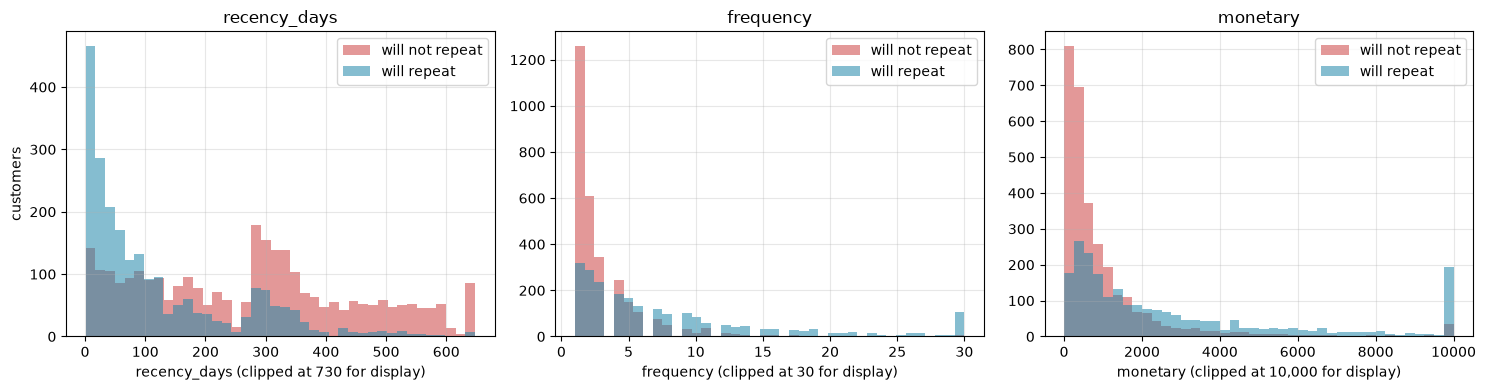

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
pdf = rfm.to_pandas()

for ax, col, cap in zip(axes, ["recency_days", "frequency", "monetary"], [730, 30, 10_000]):
    for label, name, colour in [(0, "will not repeat", "#c44"), (1, "will repeat", "#28a")]:
        values = pdf.loc[pdf["y"] == label, col].clip(upper=cap)
        ax.hist(values, bins=40, alpha=0.55, label=name, color=colour)
    ax.set_title(col)
    ax.set_xlabel(f"{col} (clipped at {cap:,} for display)")
    ax.legend()

axes[0].set_ylabel("customers")
plt.tight_layout()
plt.show()

**Result.** Recency separates the two groups visibly: repeaters pile up near zero while
non-repeaters spread across the full range with a second cluster far to the right, the
long-dormant customers. Frequency and monetary are both severely right skewed, with most
customers at the low end and a thin tail of heavy buyers.

**Consequence for Stage 6:** that skew is a problem for Logistic Regression, which fits a
linear function of the inputs, and a non-problem for gradient boosting, which only cares
about ordering. Rather than transform the data, the ratio features planned in Stage 5
(`recency_over_avg_gap`, `spend_momentum`) are naturally scale free and should help the
linear model without special handling. If the baseline underperforms badly in Stage 6, this
skew is the first thing to revisit.

## 10. The incumbent baseline: an RFM quintile heuristic

This is the rule a marketing team applies with a spreadsheet and no model: score each
customer 1 to 5 on each of R, F and M, add the scores, target the low totals. It is the
real competitor, and the Stage 0 bar requires beating it by more than fold-to-fold noise.

Building it here so Stage 6 has a concrete specification rather than a description.

**Expected:** monotonic repeat rates across the bands. If they are not monotonic, the
heuristic is not a sensible baseline and something is wrong upstream.

In [15]:
scored = rfm.with_columns(
    # Recency reversed: fewer days since last order is a better score.
    pl.col("recency_days").qcut(5, labels=["5", "4", "3", "2", "1"]).cast(pl.Utf8).cast(pl.Int32).alias("r_score"),
    pl.col("frequency").qcut(5, labels=["1", "2", "3", "4", "5"], allow_duplicates=True).cast(pl.Utf8).cast(pl.Int32).alias("f_score"),
    pl.col("monetary").qcut(5, labels=["1", "2", "3", "4", "5"]).cast(pl.Utf8).cast(pl.Int32).alias("m_score"),
).with_columns((pl.col("r_score") + pl.col("f_score") + pl.col("m_score")).alias("rfm_score"))

for dim, name in [("r_score", "Recency"), ("f_score", "Frequency"), ("m_score", "Monetary")]:
    band = scored.group_by(dim).agg(
        pl.len().alias("customers"), pl.col("y").mean().round(3).alias("repeat_rate")
    ).sort(dim)
    logger.info("%s bands (1 = worst):", name)
    display(band)

combined = scored.group_by("rfm_score").agg(
    pl.len().alias("customers"), pl.col("y").mean().round(3).alias("repeat_rate")
).sort("rfm_score")
display(combined)

18:08:33 | 01-eda | INFO | Recency bands (1 = worst):


r_score,customers,repeat_rate
i32,u32,f64
1,1056,0.132
2,1057,0.291
3,1056,0.399
4,1030,0.595
5,1084,0.748


18:08:33 | 01-eda | INFO | Frequency bands (1 = worst):


f_score,customers,repeat_rate
i32,u32,f64
1,1578,0.202
2,897,0.323
3,1006,0.417
4,747,0.558
5,1055,0.803


18:08:33 | 01-eda | INFO | Monetary bands (1 = worst):


m_score,customers,repeat_rate
i32,u32,f64
1,1057,0.184
2,1056,0.284
3,1057,0.395
4,1056,0.53
5,1057,0.777


rfm_score,customers,repeat_rate
i32,u32,f64
3,404,0.072
4,446,0.148
5,460,0.215
6,435,0.244
7,466,0.335
8,424,0.384
9,422,0.405
10,373,0.448
11,390,0.544


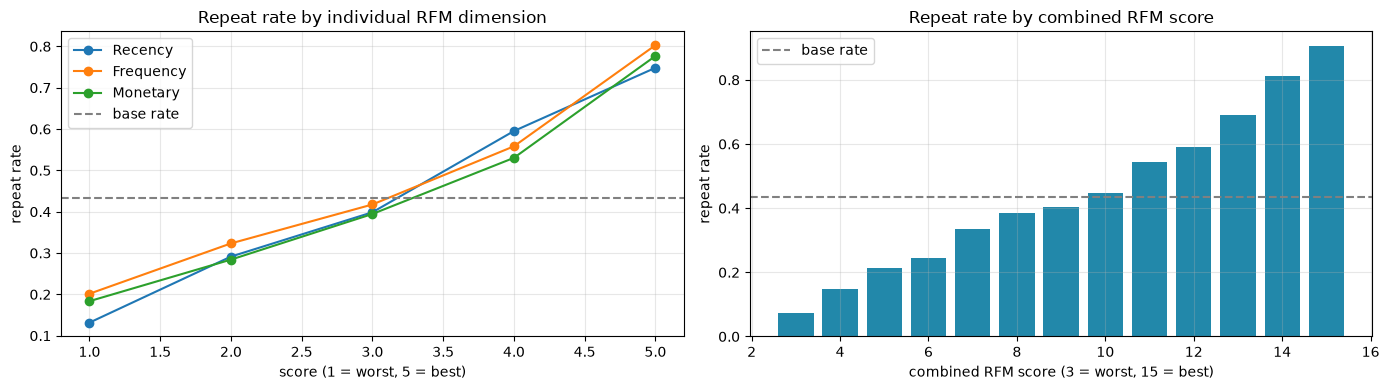

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

single = scored.to_pandas()
for dim, name in [("r_score", "Recency"), ("f_score", "Frequency"), ("m_score", "Monetary")]:
    rates = single.groupby(dim)["y"].mean()
    axes[0].plot(rates.index, rates.values, marker="o", label=name)
axes[0].axhline(single["y"].mean(), ls="--", c="grey", label="base rate")
axes[0].set_xlabel("score (1 = worst, 5 = best)")
axes[0].set_ylabel("repeat rate")
axes[0].set_title("Repeat rate by individual RFM dimension")
axes[0].legend()

comb = combined.to_pandas()
axes[1].bar(comb["rfm_score"], comb["repeat_rate"], color="#28a")
axes[1].axhline(single["y"].mean(), ls="--", c="grey", label="base rate")
axes[1].set_xlabel("combined RFM score (3 = worst, 15 = best)")
axes[1].set_ylabel("repeat rate")
axes[1].set_title("Repeat rate by combined RFM score")
axes[1].legend()

plt.tight_layout()
plt.show()

**Result. The heuristic is strong, and that is a problem worth knowing about now.**

Each dimension is cleanly monotonic:

| Score | Recency | Frequency | Monetary |
|---|---|---|---|
| 1 (worst) | 0.132 | 0.202 | 0.184 |
| 2 | 0.291 | 0.323 | 0.284 |
| 3 | 0.399 | 0.417 | 0.395 |
| 4 | 0.595 | 0.558 | 0.530 |
| 5 (best) | 0.748 | 0.803 | 0.777 |

Combined, the spread is wider still: customers scoring 3 repeat **7.2 percent** of the
time, those scoring 15 repeat **90.6 percent** of the time. A spreadsheet rule already
separates the population from 0.07 to 0.91.

This raises the bar substantially. A gradient boosted model that reaches, say, 0.80 ROC-AUC
is not obviously an improvement if the free heuristic reaches something close to it. **This
is exactly why the Stage 0 criteria require beating the incumbent by more than the
fold-to-fold standard deviation**, and it is the number Stage 6 must report honestly rather
than comparing only against the majority-class floor.

## 11. Two candidate features worth checking now

Before writing the Stage 5 feature list, two hypotheses are cheap to test and would change
what gets built.

1. **Single-order customers** should behave differently enough to deserve their own flag.
2. **Cancellation behaviour**: my prior is that customers who return things are less
   satisfied and therefore less likely to come back.

**Expected:** single-order customers repeat much less. Customers with cancellations repeat
less.

In [17]:
single_order = rfm.filter(pl.col("frequency") == 1)
multi_order = rfm.filter(pl.col("frequency") > 1)
logger.info("single-order customers: %s (%.1f%%), repeat rate %.3f",
            f"{single_order.height:,}", 100 * single_order.height / rfm.height, single_order["y"].mean())
logger.info("multi-order customers : %s (%.1f%%), repeat rate %.3f",
            f"{multi_order.height:,}", 100 * multi_order.height / rfm.height, multi_order["y"].mean())

cancels = (
    observation.filter(pl.col("invoice").str.starts_with("C"))
    .group_by("customer_id").agg(pl.col("invoice").n_unique().alias("cancel_orders"))
)
with_cancels = rfm.join(cancels, on="customer_id", how="left").with_columns(
    pl.col("cancel_orders").fill_null(0)
)
has = with_cancels.filter(pl.col("cancel_orders") > 0)
none = with_cancels.filter(pl.col("cancel_orders") == 0)
logger.info("")
logger.info("customers with at least one cancellation: %s (%.1f%%)",
            f"{has.height:,}", 100 * has.height / with_cancels.height)
logger.info("  repeat rate, has cancelled  : %.3f", has["y"].mean())
logger.info("  repeat rate, never cancelled: %.3f", none["y"].mean())

18:08:33 | 01-eda | INFO | single-order customers: 1,578 (29.9%), repeat rate 0.202


18:08:33 | 01-eda | INFO | multi-order customers : 3,705 (70.1%), repeat rate 0.533


18:08:33 | 01-eda | INFO | 


18:08:33 | 01-eda | INFO | customers with at least one cancellation: 2,238 (42.4%)


18:08:33 | 01-eda | INFO |   repeat rate, has cancelled  : 0.577


18:08:33 | 01-eda | INFO |   repeat rate, never cancelled: 0.329


**Result. The first hypothesis held; the second was backwards.**

Single-order customers are 1,578 of 5,283 (29.9 percent) and repeat only **20.2 percent** of
the time, against 53.3 percent for multi-order customers. A dedicated
`is_single_order_customer` flag is justified, and nearly a third of the population sitting
in a distinctly harder cohort is worth remembering for the Stage 9 error analysis.

The cancellation result contradicts my stated expectation. Customers who have cancelled
something repeat at **0.577**, against **0.329** for those who never have. Returning goods
is associated with being *more* likely to come back, not less.

On reflection the mechanism is obvious: cancelling requires having ordered a lot in the
first place. Cancellation count is partly a proxy for engagement volume, and that swamps
any dissatisfaction effect. This is why Stage 5 will build **`cancel_order_rate`** (a
proportion of the customer's own orders) alongside the raw count, so the model can separate
"returns often, relative to how much they buy" from "simply buys a lot".

Recording the wrong prediction here on purpose. It is a reminder for Stage 9 that when SHAP
shows cancellation features pushing predictions upward, that is the data agreeing with this
cell, not a bug.

## 12. Leakage audit

Principle 3 requires classifying every column before modeling. For this project the main
risk is **temporal rather than columnar**: there is no obvious post-outcome field in the
schema, but the entire label lives in the same table as the features, separated only by a
date.

The three ways leakage could enter here:

1. **A post-cutoff transaction reaching a feature.** The single largest risk. Guarded by
   filtering to `invoice_date < CUTOFF_DATE` before any aggregation.
2. **Recency measured against `max(invoice_date)` instead of `CUTOFF_DATE`.** The subtle
   one. Both produce plausible-looking numbers, but the first silently encodes knowledge of
   when the data ends, which at serving time does not exist.
3. **Any statistic fitted on the full table** (target encoding, product popularity, scaler
   means). None are planned; scalers go inside the pipeline in Stage 6.

Asserting the temporal guard rather than trusting it.

In [18]:
assert observation["invoice_date"].max() < CUTOFF_DATE, "observation window contains post-cutoff rows"
assert prediction["invoice_date"].min() >= CUTOFF_DATE, "prediction window contains pre-cutoff rows"
logger.info("temporal guard holds")
logger.info("  last observation timestamp : %s", observation["invoice_date"].max())
logger.info("  first prediction timestamp : %s", prediction["invoice_date"].min())

# Recency anchored correctly vs anchored to the data max: how different are they?
wrong_anchor = df["invoice_date"].max()
delta = (wrong_anchor - CUTOFF_DATE).days
logger.info("")
logger.info("if recency were anchored to max(invoice_date) instead of CUTOFF_DATE,")
logger.info("every recency value would be shifted by %d days, using information from", delta)
logger.info("inside the prediction window that would not exist at scoring time.")

18:08:33 | 01-eda | INFO | temporal guard holds


18:08:33 | 01-eda | INFO |   last observation timestamp : 2011-09-09 16:36:00


18:08:33 | 01-eda | INFO |   first prediction timestamp : 2011-09-11 10:35:00


18:08:33 | 01-eda | INFO | 


18:08:33 | 01-eda | INFO | if recency were anchored to max(invoice_date) instead of CUTOFF_DATE,


18:08:33 | 01-eda | INFO | every recency value would be shifted by 89 days, using information from


18:08:33 | 01-eda | INFO | inside the prediction window that would not exist at scoring time.


**Result.** The guard holds: the observation window ends **2011-09-09 16:36** and the
prediction window starts **2011-09-11 10:35**, with nothing crossing.

The anchoring point is quantified too. Anchoring recency to `max(invoice_date)` rather than
`CUTOFF_DATE` would shift every recency value by **89 days**, drawn from inside the
prediction window. The model would appear to work and would fail in production, because at
scoring time there is no "end of data" to measure against.

There is a day and a half of silence at the boundary, which was not planned and is worth
explaining rather than ignoring. The next cell checks why.

In [19]:
weekday_names = {1: "Monday", 2: "Tuesday", 3: "Wednesday", 4: "Thursday",
                 5: "Friday", 6: "Saturday", 7: "Sunday"}
by_weekday = (
    df.with_columns(pl.col("invoice_date").dt.weekday().alias("weekday"))
    .group_by("weekday").len().sort("weekday")
    .with_columns(pl.col("weekday").replace_strict(weekday_names).alias("day"))
    .select("day", "len")
)
display(by_weekday)

from datetime import timedelta

gap_day = CUTOFF_DATE - timedelta(days=1)
logger.info("CUTOFF_DATE     %s is a %s", CUTOFF_DATE.date(), weekday_names[CUTOFF_DATE.isoweekday()])
logger.info("the silent day  %s is a %s", gap_day.date(), weekday_names[gap_day.isoweekday()])
logger.info("rows on that day: %d",
            df.filter(pl.col("invoice_date").dt.date() == gap_day.date()).height)

day,len
str,u32
"""Monday""",189084
"""Tuesday""",196626
"""Wednesday""",185051
"""Thursday""",203149
"""Friday""",153803
"""Saturday""",402
"""Sunday""",139256


18:08:33 | 01-eda | INFO | CUTOFF_DATE     2011-09-11 is a Sunday


18:08:33 | 01-eda | INFO | the silent day  2011-09-10 is a Saturday


18:08:33 | 01-eda | INFO | rows on that day: 0


**Result, and it is a real characteristic of the business.** The retailer effectively does
not trade on Saturdays: **402 rows out of 1,067,371**, or 0.04 percent, against 139,000 to
203,000 on every other day. Sunday trading is normal.

2011-09-10, the day sitting between the two windows, is a Saturday. So the gap at the
boundary is not a data problem, it is the shop being closed.

Two things follow:

1. The cutoff placement is fine. Nothing was lost.
2. **Any day-count feature has a weekly rhythm baked into it.** `recency_days` of 1 versus
   3 can mean the same thing depending on which day the cutoff lands. At a 90-day horizon
   this is noise rather than a threat, but it is the reason not to invent
   finer-grained features like `hours_since_last_order`, which would encode a trading
   calendar the model has no way to understand.

### Column classification

| Column | Class | Disposition |
|---|---|---|
| `customer_id` | Identifier | Join key and grouping key. **Never a feature** |
| `invoice` | Transaction grain | Aggregated into `frequency` and cancellation counts, dropped as a raw field |
| `invoice_date` | Temporal | Source of every recency, tenure and momentum feature. Never used raw |
| `stock_code` | Transaction grain | Aggregated into `distinct_products`. Not used raw: per-product features on 5,283 customers would overfit badly |
| `description` | Free text | **Dropped.** Duplicates `stock_code`, is 0.41 percent null, and contains warehouse notes rather than product names |
| `quantity` | Transaction detail | Aggregated into basket-size features |
| `price` | Transaction detail | Aggregated into `avg_unit_price` |
| `country` | Categorical feature | **Kept**, pinned vocabulary with `Other` bucket |
| `source_sheet` | Artefact of loading | **Dropped.** It encodes which trading year a row came from, which is a proxy for time and could act as a crude leak |
| `line_revenue` | Derived | Aggregated into monetary features |

**No column is a duplicate of the target, and no post-outcome field exists.** The target is
constructed by us from the prediction window, so the only way to leak it is temporally, and
that is guarded above and re-asserted in Stage 5.

## 13. Stage 3 report

### Target

`y = 1` if a customer places at least one non-cancelled order in
`[2011-09-11, 2011-12-10)`. Population: 5,283 customers with a non-null `customer_id` and
at least one non-cancelled order before the cutoff. **Base rate 0.434.**

### Drop list, with reasons

| Dropped | Rows | Reason |
|---|---|---|
| Rows with null `customer_id` | 243,007 (22.8 percent) | Cannot be attributed to a customer. Only 13.7 percent of revenue, and no invoice is partially attributed, so aggregation stays clean. Applied in Stage 5 as a population filter, not in cleaning |
| `A`-prefixed invoices | 6 | Bad-debt accounting entries, not transactions. Carry -147,614 in revenue and would distort any total |
| Negative quantity without a `C` prefix | 3,457 | Warehouse write-offs (`damages`, `check`, `missing`, `smashed`). All zero price, all unattributed. Not customer returns |
| Non-product `stock_code` values | about 6,000 | Postage (`POST`, `DOT`, `C2`), fees (`M`, `D`, `S`, `BANK CHARGES`, `AMAZONFEE`, `CRUK`, `B`, `ADJUST`, `PADS`), tests (`TEST001/2`), vouchers (`gift_0001_*`) |
| `description` column | n/a | Free text, duplicates `stock_code`, contains warehouse notes |
| `source_sheet` column | n/a | Loading artefact and a crude proxy for time |
| Customers with only cancellations pre-cutoff | 63 customers | No purchase to compute recency or frequency from |

**Explicitly not dropped:** `DCGS*` and `SP1002` stock codes are **real products** despite
non-standard codes, and 12,133 duplicate rows are kept because they do not affect
invoice-level features and are more likely genuine repeated scans than an export fault.

### Data quality issues found

1. Dtype inference destroyed all 19,500 cancellation invoices at load. Fixed in Stage 2,
   guarded by `validate_raw()`.
2. Three invoice prefixes exist (numeric, `C`, `A`), not the two the documentation implies.
3. Negative quantity is **not** a reliable cancellation marker: 3,457 rows are stock
   write-offs.
4. Non-standard stock codes are a mix of fees and genuine products, so pattern matching
   alone would delete real purchases.
5. Disguised missing values in `description` (`?`, `??`, `MIA`, `wet`, `FBA`).
6. 13 customers appear under more than one country.
7. Extreme quantities are real cancelled bulk orders, not errors. **Do not clip.**
8. The business does not trade on Saturdays (402 rows in two years), so day-count features
   carry a weekly rhythm. Harmless at a 90-day horizon, but a reason not to build
   finer-grained time features.

### Candidate features for Stage 5

| Group | Features |
|---|---|
| RFM core | `recency_days`, `frequency`, `monetary_total`, `monetary_avg_per_order` |
| Lifecycle | `tenure_days`, `avg_days_between_orders`, **`recency_over_avg_gap`**, `is_single_order_customer` |
| Basket | `avg_items_per_order`, `avg_distinct_products_per_order`, `avg_unit_price`, `total_quantity`, `distinct_products` |
| Returns | `cancel_order_count`, **`cancel_order_rate`**, `return_value_ratio` |
| Momentum | `orders_last_30d/90d/180d`, `spend_last_90d`, `spend_last_365d`, `spend_momentum` |
| Activity | `distinct_active_months` |
| Categorical | `country`, pinned vocabulary plus `Other` |

### Decisions carried into later stages

1. **Stage 4 drops non-product rows by an explicit code list, never by regex**, so `DCGS*`
   products survive.
2. **Stage 4 keeps duplicate rows**, with the reasoning recorded above.
3. **Stage 5 pins `COUNTRY_VOCAB`** by minimum customer count, everything else to `Other`,
   and resolves the 13 multi-country customers by most recent country.
4. **Stage 5 builds `cancel_order_rate`**, not just the raw count, because cancellations
   proxy for engagement volume.
5. **Stage 6 must report the RFM heuristic**, not only the majority-class floor. The
   heuristic spans 0.072 to 0.906, so it is a serious competitor.
6. **Stage 9 should expect cancellation features to push predictions up.** That is this
   data's real behaviour, not a bug.

### Open questions for the next stage

- Does `recency_over_avg_gap` beat raw `recency_days`? Tenure alone is nearly useless
  (+0.044), so the ratio framing is the hypothesis being tested.
- With about 5,283 rows and roughly 850 per fold, how much of any model-to-model gap is
  real? Stage 7 must report fold standard deviations, not just mean scores.

### Exit check

| Requirement | Status |
|---|---|
| Shape, dtypes, target definition, class balance | Sections 1 and 8 |
| Missing values and disguised missing values | Section 2 |
| Distributions of numerics split by target | Section 9 and 9a |
| Target rate per categorical level | Sections 7 and 10 |
| Correlations, checked for leakage suspects | Section 9 |
| Leakage audit with every column classified | Section 12 |
| Drop list with reasons | This section |
| Candidate engineered features | This section |

All satisfied. Stage 4 (cleaning) may begin.